# Task 5: Mental Health Support Chatbot

**Objective:** Build a basic chatbot workflow that provides supportive and empathetic responses for stress, anxiety, and emotional wellness.

**Model base:** DistilGPT2 for the optional full fine-tuning script.

**Dataset:** EmpatheticDialogues for full training; this notebook uses a small local sample so it runs offline and demonstrates the same formatting/evaluation workflow.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Local Empathy Dataset Sample

The full script `finetune_empathetic.py` downloads EmpatheticDialogues and fine-tunes DistilGPT2. This notebook keeps a small sample inline so reviewers can run it without network access or a GPU.

In [2]:
examples = [
    {'context': 'anxious', 'prompt': 'I have exams soon and I cannot relax.', 'response': 'That sounds really stressful. Try breaking the next hour into one small study step and one short rest. You do not have to solve everything at once.'},
    {'context': 'sad', 'prompt': 'I feel lonely even when people are around.', 'response': 'Feeling lonely around others can be painful. Your feelings are valid, and it may help to tell one trusted person what you need instead of carrying it alone.'},
    {'context': 'overwhelmed', 'prompt': 'There is too much work and I feel stuck.', 'response': 'That is a heavy feeling. Pick one tiny task, set a ten-minute timer, and let that be enough to restart momentum.'},
    {'context': 'stressed', 'prompt': 'I keep worrying about the future.', 'response': 'Future worries can become exhausting. Bring attention back to what is controllable today, even if it is just one small action.'},
    {'context': 'tired', 'prompt': 'I feel burned out and unmotivated.', 'response': 'Burnout can make even simple tasks feel hard. Rest is not failure; it is part of recovering your energy.'},
    {'context': 'hopeful', 'prompt': 'I finally talked to a friend about my stress.', 'response': 'That is a brave and healthy step. Reaching out can make difficult emotions feel less isolating.'},
]

df = pd.DataFrame(examples)
df

,context,prompt,response
0,anxious,I have exams soon and I cannot relax.,That sounds really stressful. Try breaking the...
1,sad,I feel lonely even when people are around.,Feeling lonely around others can be painful. Y...
2,overwhelmed,There is too much work and I feel stuck.,"That is a heavy feeling. Pick one tiny task, s..."
3,stressed,I keep worrying about the future.,Future worries can become exhausting. Bring at...
4,tired,I feel burned out and unmotivated.,Burnout can make even simple tasks feel hard. ...
5,hopeful,I finally talked to a friend about my stress.,That is a brave and healthy step. Reaching out...


## 2. Format Training Text

In [3]:
def format_dialogue(row):
    return (
        f"User emotion: {row['context']}\n"
        f"User message: {row['prompt']}\n"
        f"Supportive response: {row['response']}<|endoftext|>"
    )

df['training_text'] = df.apply(format_dialogue, axis=1)
print(df.loc[0, 'training_text'])

User emotion: anxious
User message: I have exams soon and I cannot relax.
Supportive response: That sounds really stressful. Try breaking the next hour into one small study step and one short rest. You do not have to solve everything at once.<|endoftext|>


## 3. Exploratory Check of Response Tone

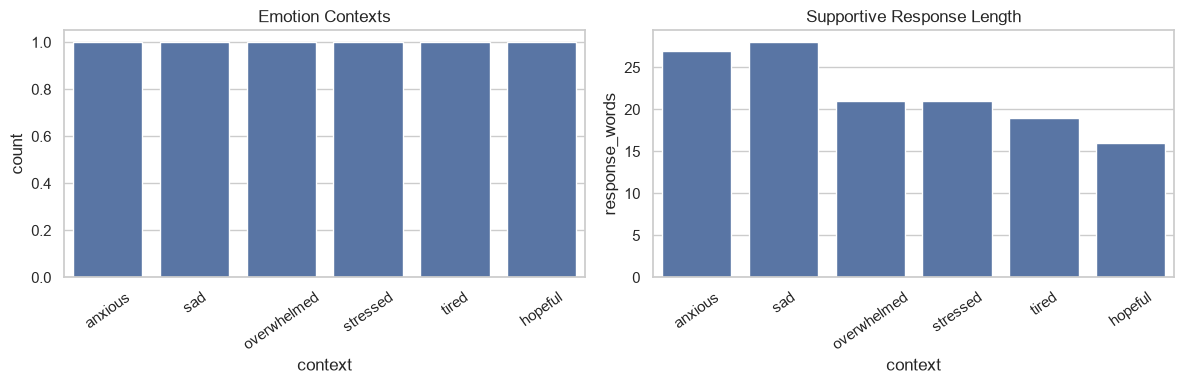

In [4]:
df['response_words'] = df['response'].str.split().str.len()
df['prompt_words'] = df['prompt'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='context', ax=axes[0])
axes[0].set_title('Emotion Contexts')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(data=df, x='context', y='response_words', ax=axes[1])
axes[1].set_title('Supportive Response Length')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 4. Safe Chatbot Prototype

In [5]:
CRISIS_TERMS = {'suicide', 'kill myself', 'self harm', 'self-harm', 'end my life', 'hurt myself'}

def contains_crisis_language(text):
    text = text.lower()
    return any(term in text for term in CRISIS_TERMS)

def supportive_reply(message):
    if contains_crisis_language(message):
        return (
            'I am really sorry you are feeling this much pain. Please contact local emergency services '
            'or a crisis helpline right now, and tell a trusted person near you if possible.'
        )

    message_lower = message.lower()
    if re.search(r'\b(anxious|panic|worried|worry)\b', message_lower):
        context = 'anxious'
    elif re.search(r'\b(sad|lonely|alone)\b', message_lower):
        context = 'sad'
    elif re.search(r'\b(overwhelmed|stuck|too much)\b', message_lower):
        context = 'overwhelmed'
    elif re.search(r'\b(tired|burned out|burnout)\b', message_lower):
        context = 'tired'
    else:
        context = 'stressed'

    match = df[df['context'] == context].iloc[0]
    return match['response']

test_messages = [
    'I am anxious about tomorrow.',
    'I feel lonely and sad.',
    'Everything feels like too much work.',
]

for message in test_messages:
    print('=' * 80)
    print('User:', message)
    print('Assistant:', supportive_reply(message))

User: I am anxious about tomorrow.
Assistant: That sounds really stressful. Try breaking the next hour into one small study step and one short rest. You do not have to solve everything at once.
User: I feel lonely and sad.
Assistant: Feeling lonely around others can be painful. Your feelings are valid, and it may help to tell one trusted person what you need instead of carrying it alone.
User: Everything feels like too much work.
Assistant: That is a heavy feeling. Pick one tiny task, set a ten-minute timer, and let that be enough to restart momentum.


## 5. Optional Fine-Tuning and Deployment

Full training is available in `finetune_empathetic.py`:

```bash
python finetune_empathetic.py
streamlit run app.py
```

The Streamlit app uses the fine-tuned model if `empathetic_model/` exists. Otherwise, it uses the same safe local fallback demonstrated above.

## 6. Results and Insights

- The dataset is formatted into prompt-response pairs suitable for causal language-model fine-tuning.
- The chatbot prioritizes validation, gentle suggestions, and safety boundaries.
- Crisis language receives an urgent support message instead of normal chatbot output.
- The project is educational and is not a replacement for therapy, diagnosis, or emergency care.